In [1]:
%%time
%load_ext autoreload
%autoreload 2

import pandas as pd
import wandb
import pandas as pd
from collections import defaultdict

# Table processing
def process_line(means, highlight, highlight_index, highlight_max, ignore_std):
    if highlight:
        if highlight_max:
            tops = set(means.groupby(highlight_index).idxmax())
        else:
            tops = set(means.groupby(highlight_index).idxmin())
    else:
        tops = set()

    def process_line(x):
        if ignore_std:
            if x.name in tops:
                return rf"\textbf{{{x['mean']:0.3f}}}"
            return rf"{x['mean']:0.3f}"
        if x.name in tops:
            return rf"\textbf{{{x['mean']:0.3f} $\pm$ {x['std']:0.3f}}}"
        return rf"{x['mean']:0.3f} $\pm$ {x['std']:0.3f}"

    return process_line


def mean_pm_std(
    data,
    index,
    columns,
    value,
    highlight=True,
    highlight_cols=True,
    highlight_max=True,
    ignore_std=False,
):
    assert len(data) > 0
    groupby = data.groupby([*index, *columns])
    means = groupby.mean()[value].rename("mean")
    stds = groupby.std()[value].rename("std")
    ddf = pd.concat([means, stds], axis=1).T
    highlight_index = columns if highlight_cols else index
    ddf = ddf.apply(
        process_line(means, highlight, highlight_index, highlight_max, ignore_std)
    )
    ddf = ddf.reset_index().pivot(index=index, columns=columns)
    ddf.columns = ddf.columns.droplevel(level=0)
    
    return ddf

    
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def prepare_data(data):
    flattened_data = [flatten_dict(item) for item in data]
    return pd.DataFrame(flattened_data)



CPU times: user 1.77 s, sys: 198 ms, total: 1.97 s
Wall time: 858 ms


In [2]:
api = wandb.Api(timeout=180)

# Project is specified by <entity/project-name>
runs = api.runs(
    "openproblems-comp/fast-tbg",
    filters={
        "$and": [
            {
                # "created_at": {"$gt": "2025-01-26T00:00:00"},
                "tags": {"$in": ["jarz_num_samples_v2", "v22"], "$nin": ["outlier"]},
                #'group': {'$in': ['5_vars']},
                # "config.data.n_particles": {"$eq": 22},
                #'config.model': {'$eq': model},
                #'config.lr': {'$lt': 1.01 * lr, '$gt': 0.99 * lr},
            }
        ]
    },
)

summary_list, config_list, name_list, tag_list = [], [], [], []
for run in runs:
    tag_list.append(run.tags)
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)
    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
    # .name is the human-readable name of the run.
    name_list.append(run.name)
df_summary = prepare_data(summary_list)
df_config = prepare_data(config_list)
tag_list = [str(t) for t in tag_list]
df = pd.concat(
    [
        pd.DataFrame(name_list, columns=["name"]),
        pd.DataFrame(tag_list, columns=["Tags"]),
        df_summary,
        df_config,
    ],
    axis=1,
)

In [29]:
metrics = [
    "test/cropped_energy_w1",
    "test/rama/torus_wasserstein",
    "test/resampled/energy_w1",
    "test/resampled/rama/torus_wasserstein",
    "test/jarzynski/energy_w1",
    "test/jarzynski/rama/torus_wasserstein",
    "test/jarzynski/effective_sample_size",
    "test/jarzynski/rama/torus_wasserstein",
]

In [30]:
import math

def filterer(x):
    if isinstance(x, float) and not math.isfinite(x):
        return False
    return "table" in list(x)


filtered_df = df[
    # df["model/_target_"].isin(["src.models.flow_matching_module.FlowMatchLitModule"])
    # & df["Tags"].apply(lambda x: "eval" in x)
    df["Tags"].apply(lambda x: True)
    # & ~df["val/cropped_energy_w1"].isna()
    # & df["tags"].apply(filterer)
][
    [
        # "tags",
        "model/_target_",
        "model/net/_target_",
        "data/n_particles",
        "model/sampling_config/num_test_proposal_samples",
        "model/use_com_energy",
        "model/clip_logits",
        *metrics,
    ]
].drop(
    columns=["model/_target_"]
)

# filtered_df.sort_values("data/n_particles")

In [31]:
renamed_df = filtered_df.replace(
    {
        "src.models.components.tbg.egnn_dynamics_ad2_cat.EGNN_dynamics_AD2_cat": "EQ-CFM",
        "src.models.components.dit.DIT3D": "DiT-CFM",
        "src.models.components.tarflow.TarFlow": "TarFlow",
    }
).rename(
    columns={
        "model/net/_target_": "Model",
        "data/n_particles": "n_particles",
        "model/sampling_config/num_test_proposal_samples": "num_test_proposal_samples",
    }
)

In [32]:
renamed_df = renamed_df[
    ((renamed_df["Model"] == "TarFlow") &
    (renamed_df["model/clip_logits"] == 0.002) &
    (renamed_df["model/use_com_energy"] == 1))
    | (renamed_df["Model"] != "TarFlow")
]

In [33]:
renamed_df.groupby(["Model", "num_test_proposal_samples"]).count()

n_particles  model/use_com_energy  \
Model   num_test_proposal_samples                                      
EQ-CFM  100                                  3                     0   
        200                                  3                     0   
        500                                  3                     0   
        1000                                 3                     0   
        2000                                 3                     0   
        5000                                 3                     0   
        10000                                3                     0   
        20000                                3                     0   
TarFlow 100                                  6                     6   
        200                                  6                     6   
        500                                  6                     6   
        1000                                 6                     6   
        2000                                 6                     6   
        5000                                 6                     6   
        10000                                6                     6   
        20000                                6                     6   
        50000                                6                     6   
        100000                               6                     6   
        200000                               6                     6   

                                   model/clip_logits  test/cropped_energy_w1  \
Model   num_test_proposal_samples                                              
EQ-CFM  100                                        3                       3   
        200                                        3                       3   
        500                                        3                       3   
        1000                                       3                       3   
        2000                                       3                       3   
        5000                                       3                       3   
        10000                                      3                       3   
        20000                                      3                       3   
TarFlow 100                                        6                       6   
        200                                        6                       6   
        500                                        6                       6   
        1000                                       6                       6   
        2000                                       6                       6   
        5000                                       6                       6   
        10000                                      6                       6   
        20000                                      6                       6   
        50000                                      6                       6   
        100000                                     6                       6   
        200000                                     6                       6   

                                   test/rama/torus_wasserstein  \
Model   num_test_proposal_samples                                
EQ-CFM  100                                                  3   
        200                                                  3   
        500                                                  3   
        1000                                                 3   
        2000                                                 3   
        5000                                                 3   
        10000                                                3   
        20000                                                3   
TarFlow 100                                                  6   
        200                                                  6   
        500                                      

num_test_proposal_samples
100       2.360466
200       2.011672
500       2.465588
1000      1.701092
2000      1.921170
5000      1.670017
10000     1.512892
20000     1.498366
50000     1.353681
100000    1.499897
Name: test/jarzynski/energy_w1, dtype: float64
num_test_proposal_samples
100      2.869865
200      2.071197
500      2.325917
1000     3.654931
2000     0.923196
5000     1.478909
10000    1.596296
20000    1.432858
Name: test/resampled/energy_w1, dtype: float64
                           test/jarzynski/rama/torus_wasserstein  \
num_test_proposal_samples                                          
100                                                     2.529015   
200                                                     2.388377   
500                                                     2.084171   
1000                                                    1.923987   
2000                                                    1.729894   
5000                                        

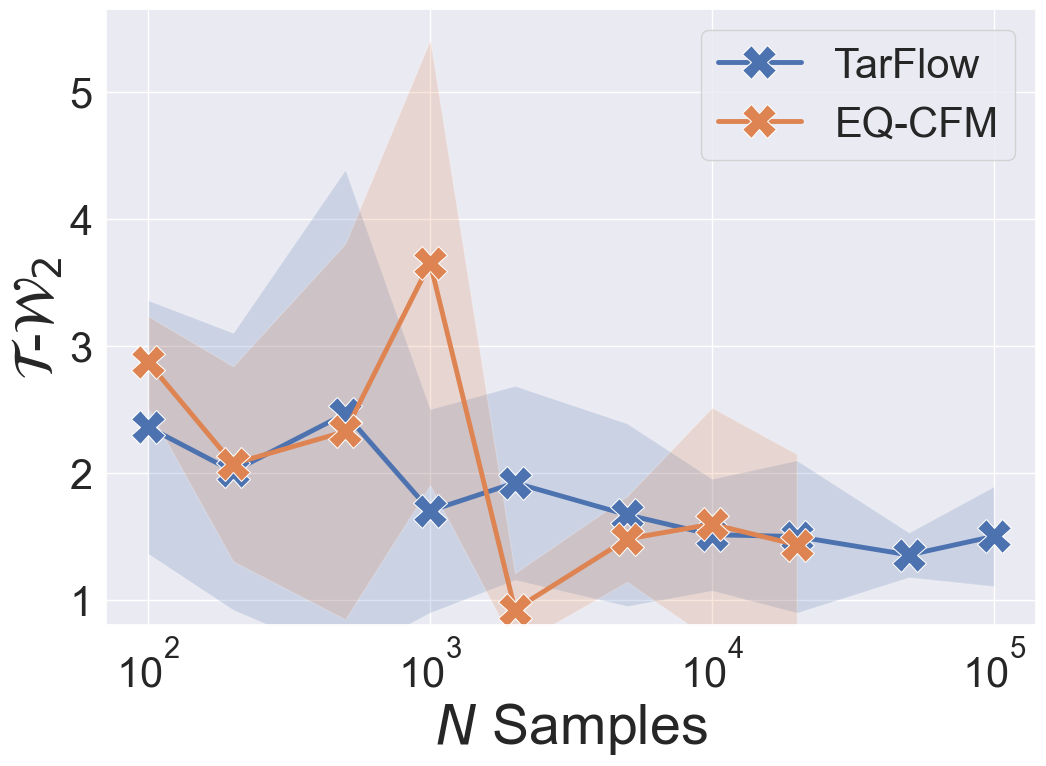

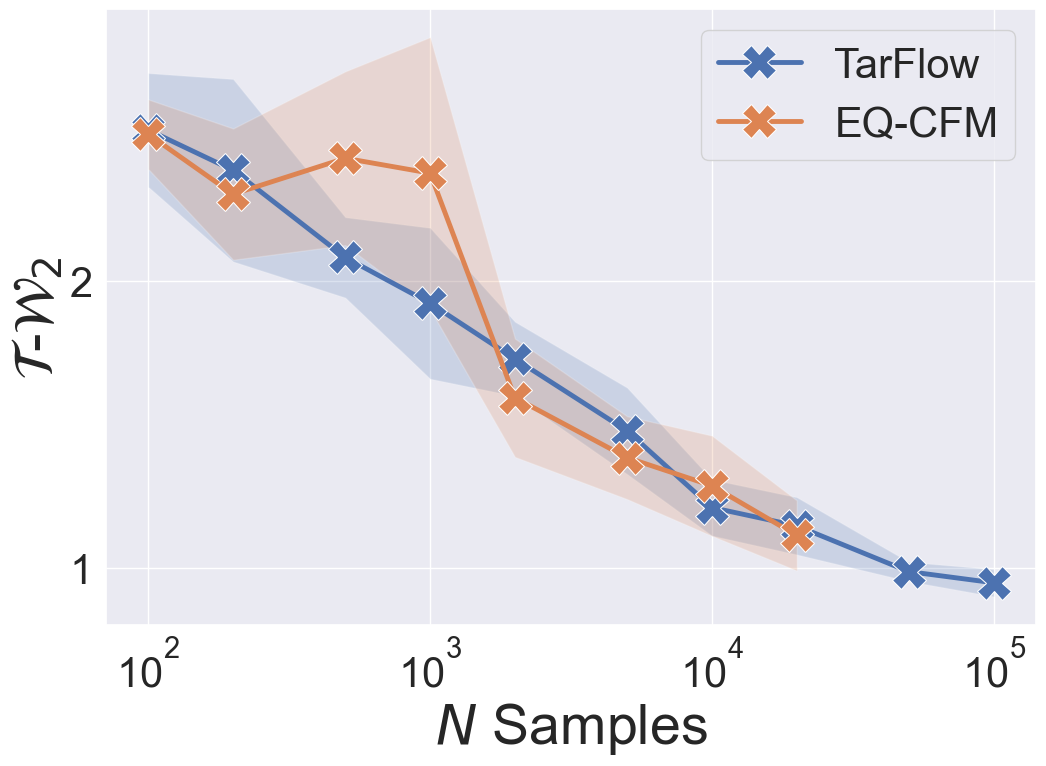

In [34]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

renamed_df = renamed_df[renamed_df["num_test_proposal_samples"] <= 100_000]

for n_particles in [33]:
    for metric_name in ["energy_w1", "rama/torus_wasserstein"]:

        fig = plt.figure(figsize=(12, 8))
        ax = plt.subplot()
        sns.set_theme(style="darkgrid")

        for label in (ax.get_xticklabels()):
            label.set_fontname('Arial')
            label.set_fontsize(30)
        for label in (ax.get_yticklabels()):
            label.set_fontname('Arial')
            label.set_fontsize(30)

        ax.xaxis.get_offset_text().set_fontsize(5)
        ax.yaxis.get_offset_text().set_fontsize(5)
        axis_font = {'fontname': 'Arial', 'size': '40'}

        for model in renamed_df["Model"].unique():

            if model == "TarFlow":
                metric_prefix = "test/jarzynski"
            else:
                metric_prefix = "test/resampled"

            metric = f"{metric_prefix}/{metric_name}"

            particles_df = renamed_df[
                (renamed_df["n_particles"] == n_particles)
                & (renamed_df["Model"] == model)
            ]

            particles_df = particles_df.drop(columns=["Model"])

            particles_df = particles_df.groupby(["num_test_proposal_samples"])
            means = particles_df.mean()[metric]
            stds = particles_df.std()[metric]

            print(means)

            if len(means.shape) == 2:
                means = means.iloc[:, 0]
                stds = stds.iloc[:, 0]

            sns.lineplot(
                x = means.index,
                y = means,
                label=model,
                markers=True,
                marker='X', linewidth=3.5, markersize=24
            )
            plt.fill_between(
                means.index,
                means - stds,
                means + stds,
                alpha=0.2,
            )
        ax.set_xlabel('$N$ Samples', **axis_font)

        if metric == "test/jarzynski/energy_w1":
            ax.set_ylabel('$\mathcal{E}$-$\mathcal{W}_1$', **axis_font)
        else:
            ax.set_ylabel('$\mathcal{T}$-$\mathcal{W}_2$', **axis_font)
            ax.set_ylim(bottom=0.8)
#         plt.xlabel("N Samples")
#         plt.ylabel("Energy W1")
        plt.xscale("log")
        ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
        # plt.yscale("log")

        plt.legend(loc='best', prop={'size': 30})
        # plt.show()
        plot_name = 'Energy_vs_samples'
        plt.savefig(plot_name +".png", bbox_inches='tight')